# Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.executable
sys.path.append('../')
from SRC import Limpieza as lp


In [3]:
import openpyxl
openpyxl.__version__
pd.__version__

'3.0.0'

# Carga de datos #

# 1.Campañas de marketing #

# Columnas del dataset  #

age: La edad del cliente.

job: La ocupación o profesión del cliente.

marital: El estado civil del cliente.

education: El nivel educativo del cliente.

default: Indica si el cliente tiene algún historial de incumplimiento de pagos (1: Sí, 0: No).

housing: Indica si el cliente tiene un préstamo hipotecario (1: Sí, 0: No).

loan: Indica si el cliente tiene algún otro tipo de préstamo (1: Sí, 0: No).

contact: El método de contacto utilizado para comunicarse con el cliente.

duration: La duración en segundos de la última interacción con el cliente.

campaign: El número de contactos realizados durante esta campaña para este cliente.

pdays: Número de días que han pasado desde la última vez que se contactó con el cliente durante esta campaña.

previous: Número de veces que se ha contactado con el cliente antes de esta campaña.

poutcome: Resultado de la campaña de marketing anterior.

emp.var.rate: La tasa de variación del empleo.

cons.price.idx: El índice de precios al consumidor.

cons.conf.idx: El índice de confianza del consumidor.

euribor3m: La tasa de interés de referencia a tres meses.

nr.employed: El número de empleados.

y: Indica si el cliente ha suscrito un producto o servicio (Sí/No).

date: La fecha en la que se realizó la interacción con el cliente.


id_: Un identificador único para cada registro en el dataset.

In [4]:
df_marketing = pd.read_csv('../Datos/raw/bank-additional.csv')

In [5]:
df_marketing.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [6]:
df_marketing.shape

(43000, 24)

In [7]:
df_marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [8]:
df_marketing.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [9]:
df_marketing.columns

Index(['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude',
       'longitude', 'id_'],
      dtype='str')

In [10]:
df_marketing.columns = (
    df_marketing.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('.', '_', regex=False)
)
df_marketing.columns

Index(['unnamed:_0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'date', 'latitude',
       'longitude', 'id_'],
      dtype='str')

In [11]:
df_marketing.rename(columns={'id_': 'id'}, inplace=True)
df_marketing.columns

Index(['unnamed:_0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'date', 'latitude',
       'longitude', 'id'],
      dtype='str')

# Duplicados

In [12]:
df_marketing.duplicated().sum()

np.int64(0)

VALORES NULOS 

In [13]:
df_marketing.isnull().sum()

unnamed:_0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx     471
cons_conf_idx        0
euribor3m         9256
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id                   0
dtype: int64

In [14]:
""""mejor visualización de valores nulos para análisis exploratorio"""
df_marketing.isnull().sum()/len(df_marketing)*100

unnamed:_0         0.000000
age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp_var_rate       0.000000
cons_price_idx     1.095349
cons_conf_idx      0.000000
euribor3m         21.525581
nr_employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id                 0.000000
dtype: float64

Se imputan los valores nulos de variables categóricas con 'unknown' debido a su bajo porcentaje de ausencia, evitando sesgos en el análisis. 

In [15]:
"""Manejo de valores nulos en variables categóricas"""

def categorical_cols(df, columnas):
    for col in columnas:
        df[col] = df[col].fillna('unknown')
    return df
 
categorical_cols_list = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan'
]


In [16]:
df_marketing = categorical_cols(df_marketing, categorical_cols_list)

In [17]:
df_marketing.isnull().sum()

unnamed:_0           0
age               5120
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx     471
cons_conf_idx        0
euribor3m         9256
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id                   0
dtype: int64

In [18]:
"""Se completa el valor nulo de la variable 'euribor3m' con el dato faltante que es el mismo en todos los casos"""

df_marketing['euribor3m']= df_marketing ['euribor3m'].fillna(4.857)

In [19]:
"""Se completa el valor nulo de la variable 'age' con la mediana de la misma"""

df_marketing['age'] = df_marketing['age'].fillna(df_marketing['age'].median())

In [20]:
""" Se cambia el formato de la variable 'cons_price_idx' para convertirla a numérica """

df_marketing['cons_price_idx'] = df_marketing['cons_price_idx'].astype(str).str.replace(',', '.').str.strip()

df_marketing['cons_price_idx'] = pd.to_numeric(df_marketing['cons_price_idx'], errors='coerce')

In [21]:
"""Se completa el valor nulo de la variable 'cons_price_idx' con la mediana de la misma"""

df_marketing['cons_price_idx'] = df_marketing['cons_price_idx'].fillna(df_marketing['cons_price_idx'].median())

In [22]:
df_marketing.isnull().sum()

unnamed:_0          0
age                 0
job                 0
marital             0
education           0
default             0
housing             0
loan                0
contact             0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp_var_rate        0
cons_price_idx      0
cons_conf_idx       0
euribor3m           0
nr_employed         0
y                   0
date              248
latitude            0
longitude           0
id                  0
dtype: int64

In [23]:
"""Tramiento de columna date"""

df_marketing["date"].head()

0         2-agosto-2019
1    14-septiembre-2016
2       15-febrero-2019
3     29-noviembre-2015
4         29-enero-2017
Name: date, dtype: str

In [24]:
"""Creación de diccionario de meses"""
meses = {
    "enero": "01",
    "febrero": "02",
    "marzo": "03",
    "abril": "04",
    "mayo": "05",
    "junio": "06",
    "julio": "07",
    "agosto": "08",
    "septiembre": "09",
    "octubre": "10",
    "noviembre": "11",
    "diciembre": "12"
}


In [25]:
"""Normalización de texto en columna date"""

df_marketing["date"] = (
    df_marketing["date"]
    .str.lower()
    .str.strip()
)


In [26]:
"""Reemplazo de meses en texto por meses en número"""

for mes_texto, mes_num in meses.items():
    df_marketing["date"] = df_marketing["date"].str.replace(
        f"-{mes_texto}-",
        f"-{mes_num}-",
        regex=False
    )


In [27]:
"""Verificación de cambios en columna date"""

df_marketing["date"].head()

0     2-08-2019
1    14-09-2016
2    15-02-2019
3    29-11-2015
4    29-01-2017
Name: date, dtype: str

In [28]:
"""Convertir columna date a formato fecha"""

df_marketing["date"] = pd.to_datetime(
    df_marketing["date"],
    format="%d-%m-%Y",
    errors="coerce"
)
df_marketing["date"].head()

0   2019-08-02
1   2016-09-14
2   2019-02-15
3   2015-11-29
4   2017-01-29
Name: date, dtype: datetime64[us]

In [29]:
df_marketing["date"].isna().sum()


np.int64(248)

Las fechas nulas no fueron eliminadas ya que pueden reflejar incidencias operativas en la campaña de marketing.
Se creó una variable indicadora para identificar estos casos y se imputó la fecha mediante la mediana únicamente para permitir el análisis temporal, preservando la información original.

In [30]:
def impute_date_with_median(df, date_col):
    """
    Imputa valores nulos en una variable de fecha utilizando la mediana,
    creando previamente una variable indicadora y generando features temporales
    para análisis.
    """
    # Variable indicadora: 1 si la fecha es nula, 0 si no
    df[f'{date_col}_missing'] = df[date_col].isnull().astype(int)

    # Cálculo de la mediana
    fecha_mediana = df[date_col].median()

    # Imputación de la fecha
    df[f'{date_col}_imputed'] = df[date_col].fillna(fecha_mediana)

    # Variables temporales
    df['year'] = df[f'{date_col}_imputed'].dt.year
    df['month'] = df[f'{date_col}_imputed'].dt.month
    df['weekday'] = df[f'{date_col}_imputed'].dt.day_name()

    return df


In [31]:
df_marketing = impute_date_with_median(df_marketing, 'date')
df_marketing[['date', 'date_missing', 'date_imputed', 'year', 'month', 'weekday']].head()

,date,date_missing,date_imputed,year,month,weekday
0,2019-08-02,0,2019-08-02,2019,8,Friday
1,2016-09-14,0,2016-09-14,2016,9,Wednesday
2,2019-02-15,0,2019-02-15,2019,2,Friday
3,2015-11-29,0,2015-11-29,2015,11,Sunday
4,2017-01-29,0,2017-01-29,2017,1,Sunday


Normalizar datos

In [32]:
"""Normalización de datos 1 y 0 por "yes" y "no" """

df_marketing["default"] = df_marketing["default"].replace({1.0: "yes", 0.0: "no"})
df_marketing["housing"] = df_marketing["housing"].replace({1.0: "yes", 0.0: "no"})
df_marketing["loan"] = df_marketing["loan"].replace({1.0: "yes", 0.0: "no"})

In [33]:
"""Normalización de "age"""""

df_marketing["age"] = df_marketing["age"].astype(int)
df_marketing["age"].head()

0    38
1    57
2    37
3    40
4    56
Name: age, dtype: int64

In [34]:
"""Normalización de "education" """

df_marketing["education"] = df_marketing["education"].replace({
    "basic.4y": "basic",
    "basic.6y": "basic",
    "basic.9y": "basic",
    "high.school": "high school",
    "illiterate": "unknown"
})
df_marketing["education"].value_counts()

education
basic                  13051
university.degree      12722
high school             9925
professional.course     5477
unknown                 1825
Name: count, dtype: int64

In [35]:
df_marketing.head()

,unnamed:_0,age,job,marital,education,default,housing,loan,contact,duration,...,y,date,latitude,longitude,id,date_missing,date_imputed,year,month,weekday
0,0,38,housemaid,MARRIED,basic,no,no,no,telephone,261,...,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,2019-08-02,2019,8,Friday
1,1,57,services,MARRIED,high school,unknown,no,no,telephone,149,...,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,0,2016-09-14,2016,9,Wednesday
2,2,37,services,MARRIED,high school,no,yes,no,telephone,226,...,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,0,2019-02-15,2019,2,Friday
3,3,40,admin.,MARRIED,basic,no,no,no,telephone,151,...,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,0,2015-11-29,2015,11,Sunday
4,4,56,services,MARRIED,high school,no,no,yes,telephone,307,...,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,0,2017-01-29,2017,1,Sunday


In [36]:
df_marketing.info()
df_marketing.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   unnamed:_0      43000 non-null  int64         
 1   age             43000 non-null  int64         
 2   job             43000 non-null  str           
 3   marital         43000 non-null  str           
 4   education       43000 non-null  str           
 5   default         43000 non-null  object        
 6   housing         43000 non-null  object        
 7   loan            43000 non-null  object        
 8   contact         43000 non-null  str           
 9   duration        43000 non-null  int64         
 10  campaign        43000 non-null  int64         
 11  pdays           43000 non-null  int64         
 12  previous        43000 non-null  int64         
 13  poutcome        43000 non-null  str           
 14  emp_var_rate    43000 non-null  float64       
 15  cons_price_id

unnamed:_0        41032
age                  78
job                  12
marital               4
education             5
default               3
housing               3
loan                  3
contact               2
duration           1540
campaign             42
pdays                27
previous              8
poutcome              3
emp_var_rate         10
cons_price_idx       26
cons_conf_idx        26
euribor3m           310
nr_employed          11
y                     2
date               1825
latitude          20491
longitude         30448
id                43000
date_missing          2
date_imputed       1825
year                  5
month                12
weekday               7
dtype: int64

Archivo de dataset clean

In [37]:
df_marketing.to_csv(
    "../Datos/output/df_marketing_clean.csv",
    index=False
)


# 2.Características del cliente #

# Columnas del dataset  #

Income: Representa el ingreso anual del cliente en términos monetarios.

Kidhome: Indica el número de niños en el hogar del cliente.

Teenhome: Indica el número de adolescentes en el hogar del cliente.

Dt_Customer: Representa la fecha en que el cliente se convirtió en cliente de la empresa.

NumWebVisitsMonth: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.

ID: Identificador único del cliente.

In [38]:
df_customers = pd.read_excel('../Datos/raw/customer-details.xlsx')

In [39]:
xls = pd.read_excel(
    '../Datos/raw/customer-details.xlsx',
    sheet_name=None
)

In [40]:
""" VISTA DE LAS HOJAS DEL ARCHIVO EXCEL """

xls.keys()

dict_keys(['2012', '2013', '2014'])

In [41]:
df_customers.shape

(20115, 7)

In [42]:
""" CONCATENAR LAS HOJAS DEL ARCHIVO EXCEL EN UN SOLO DATAFRAME """

df_customers = pd.concat(
    xls.values(),
    ignore_index=True
)

In [43]:
df_customers.shape

(43170, 7)

In [44]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 2.3 MB


In [45]:
df_customers.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [46]:
df_customers.columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'ID'],
      dtype='str')

In [47]:
df_customers.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [48]:
df_customers.duplicated().sum()

np.int64(0)

In [49]:
df_customers.columns = (
    df_customers.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('.', '_', regex=False)
)


In [50]:
df_customers.columns

Index(['unnamed:_0', 'income', 'kidhome', 'teenhome', 'dt_customer',
       'numwebvisitsmonth', 'id'],
      dtype='str')

In [51]:
df_customers.to_csv(
    "../Datos/output/df_customers_clean.csv",
    index=False
)


In [52]:
df_customers['id'].dtype

<StringDtype(storage='python', na_value=nan)>

Comprobación de datos previas al cruce de los dataframe

In [53]:
df_marketing['id'].unique()


<StringArray>
['089b39d8-e4d0-461b-87d4-814d71e0e079',
 'e9d37224-cb6f-4942-98d7-46672963d097',
 '3f9f49b5-e410-4948-bf6e-f9244f04918b',
 '9991fafb-4447-451a-8be2-b0df6098d13e',
 'eca60b76-70b6-4077-80ba-bc52e8ebb0eb',
 'd63ede72-0b6d-45b1-8872-385ac6897f65',
 '5e3483e5-236d-437d-8351-541f9d09b9dd',
 '87fdc08b-30ae-4dab-803f-561ecdf27ff0',
 '87b79988-2be5-419d-88f4-56655852c565',
 'ea6b7d04-9271-4c0a-a01f-07795d164aba',
 ...
 '649cf395-b67a-416c-b9ae-3eaf6d3661c5',
 '12d4e85c-39d9-4193-a27d-a58e7af15a43',
 '8b6538f1-e279-4087-8082-659870ab3881',
 '0490dbb9-e21d-4b59-a402-93756e8f17da',
 'd9f2c31c-7623-44df-9240-b4514bf21abd',
 '4eed05de-2a98-4227-b488-32122009b638',
 '0f0aca88-4088-4fe2-905f-44fb675d9493',
 'cadadd4b-7ee5-4019-b13a-ca01bb67ca5b',
 '5f432048-d515-4bb5-9c94-62db451f88d4',
 '993bbbd6-4dbc-4a40-a408-f91f8462bee6']
Length: 43000, dtype: str

In [54]:
df_customers['id'].unique()


<StringArray>
['089b39d8-e4d0-461b-87d4-814d71e0e079',
 'e9d37224-cb6f-4942-98d7-46672963d097',
 '3f9f49b5-e410-4948-bf6e-f9244f04918b',
 '9991fafb-4447-451a-8be2-b0df6098d13e',
 'eca60b76-70b6-4077-80ba-bc52e8ebb0eb',
 'd63ede72-0b6d-45b1-8872-385ac6897f65',
 '5e3483e5-236d-437d-8351-541f9d09b9dd',
 '87fdc08b-30ae-4dab-803f-561ecdf27ff0',
 '87b79988-2be5-419d-88f4-56655852c565',
 'ea6b7d04-9271-4c0a-a01f-07795d164aba',
 ...
 '0490dbb9-e21d-4b59-a402-93756e8f17da',
 'd9f2c31c-7623-44df-9240-b4514bf21abd',
 '4eed05de-2a98-4227-b488-32122009b638',
 '0f0aca88-4088-4fe2-905f-44fb675d9493',
 'cadadd4b-7ee5-4019-b13a-ca01bb67ca5b',
 '5f432048-d515-4bb5-9c94-62db451f88d4',
 '993bbbd6-4dbc-4a40-a408-f91f8462bee6',
 'd6271666-319d-42c8-a741-cb22bf2c2093',
 'f67fbfa8-6573-414d-a805-b26a2f1b1ceb',
 '9727bc06-c11a-461a-a5bb-3d210467cc2a']
Length: 43170, dtype: str

# Se guardan los dataset limpios

In [55]:
df_marketing_clean = pd.read_csv("../Datos/output/df_marketing_clean.csv")

In [56]:
df_customers_clean = pd.read_csv("../Datos/output/df_customers_clean.csv")

# Análisis descriptivo

In [57]:
"""Variable objetivo"""

df_marketing["y"].value_counts(normalize=True)

y
no     0.887349
yes    0.112651
Name: proportion, dtype: float64

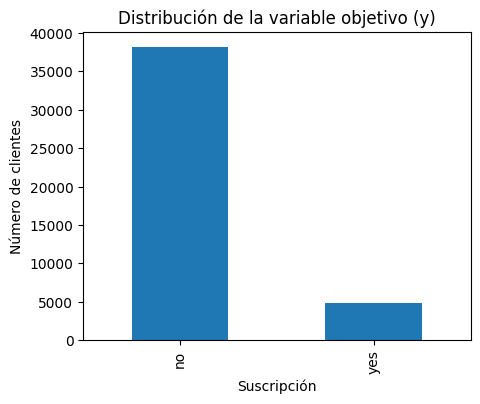

In [58]:
plt.figure(figsize=(5,4))
df_marketing["y"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo (y)")
plt.xlabel("Suscripción")
plt.ylabel("Número de clientes")
plt.show()


El dataset está desbalanceado, con una clara mayoría de campañas sin conversión, algo habitual en datos reales de marketing.

In [59]:
cat_cols = ["job", "education", "marital", "contact"]

for col in cat_cols:
    display(
        pd.crosstab(
            df_marketing[col],
            df_marketing["y"],
            normalize="index"
        ).round(3)
    )


y,no,yes
job,,
admin.,0.870,0.130
blue-collar,0.931,0.069
entrepreneur,0.917,0.083
housemaid,0.901,0.099
management,0.888,0.112
retired,0.748,0.252
self-employed,0.892,0.108
services,0.919,0.081
student,0.687,0.313


y,no,yes
education,,
basic,0.913,0.087
high school,0.892,0.108
professional.course,0.887,0.113
university.degree,0.863,0.137
unknown,0.855,0.145


y,no,yes
marital,,
DIVORCED,0.898,0.102
MARRIED,0.898,0.102
SINGLE,0.861,0.139
unknown,0.847,0.153


y,no,yes
contact,,
cellular,0.853,0.147
telephone,0.948,0.052


Existen diferencias en la tasa de suscripción según perfil socio-laboral y nivel educativo.

# Análisis cuantitativo

In [60]:
df_marketing_clean.groupby("y")[[
    "age",
    "duration",
    "campaign",
    "previous"
]].mean().round(2)


,age,duration,campaign,previous
y,,,,
no,39.64,220.43,2.63,0.13
yes,40.54,551.62,2.05,0.50


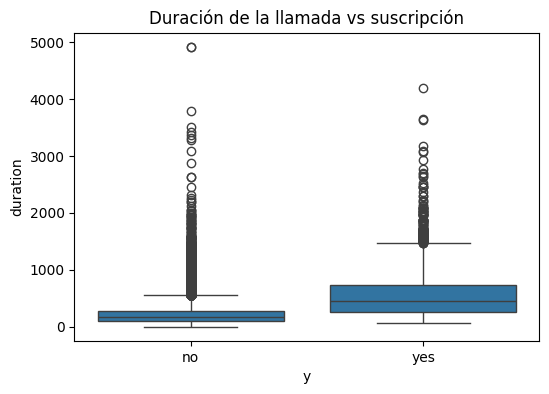

In [61]:
""""Duración de la llamada vs suscripción"""

plt.figure(figsize=(6,4))
sns.boxplot(data=df_marketing_clean, x="y", y="duration")
plt.title("Duración de la llamada vs suscripción")
plt.show()

La duración del contacto es la variable más claramente asociada a la conversión.

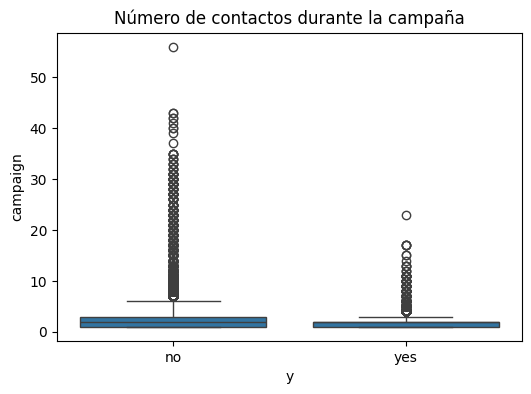

In [62]:
""""Número de contactos en campaña"""

plt.figure(figsize=(6,4))
sns.boxplot(data=df_marketing_clean, x="y", y="campaign")
plt.title("Número de contactos durante la campaña")
plt.show()


In [79]:
num_cols = df_marketing_clean.select_dtypes(include=np.number)

In [80]:
num_cols.columns = num_cols.columns.astype(str)

In [81]:
num_cols = num_cols.loc[:, ~num_cols.columns.str.lower().str.contains("unnamed")]

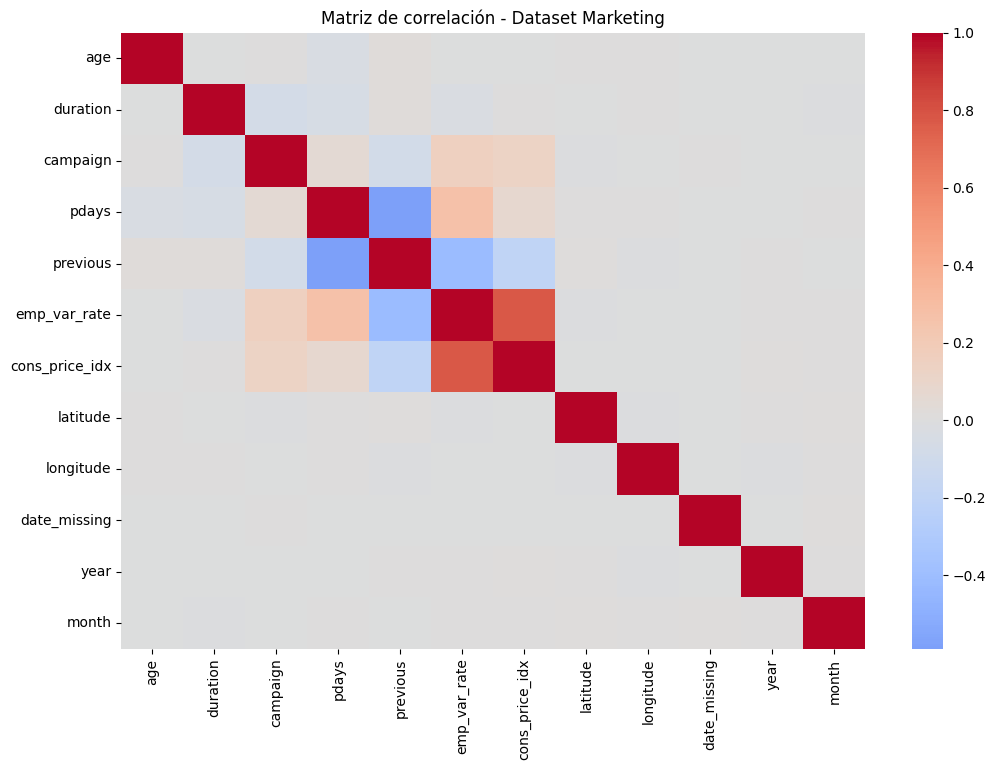

In [83]:
corr = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación - Dataset Marketing")
plt.show()


In [76]:
df_customers_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
unnamed:_0,43170.0,7916.022469,5228.248885,0.0,3597.0,7194.5,11705.75,20114.0
income,43170.0,93227.389622,50498.181989,5841.0,49608.0,93009.5,136740.50,180802.0
kidhome,43170.0,1.004749,0.815996,0.0,0.0,1.0,2.00,2.0
teenhome,43170.0,0.998633,0.816008,0.0,0.0,1.0,2.00,2.0
numwebvisitsmonth,43170.0,16.591290,9.241769,1.0,9.0,17.0,25.00,32.0


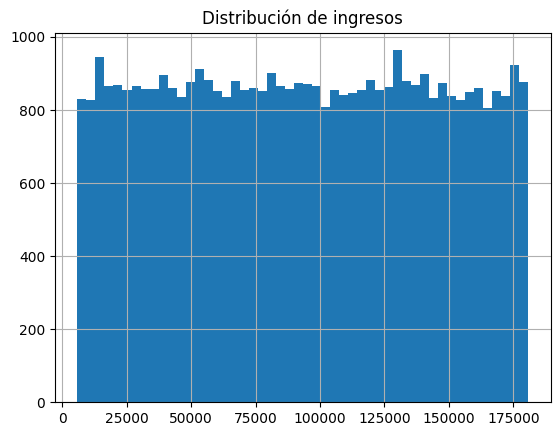

In [63]:

df_customers_clean["income"].hist(bins=50)
plt.title("Distribución de ingresos")
plt.show()


Distribución asimétrica, con concentración en tramos medios.

In [64]:
df_customers_clean[["kidhome", "teenhome"]].value_counts()


kidhome  teenhome
2        1           4886
         0           4825
1        2           4817
         0           4805
         1           4803
0        0           4772
2        2           4764
0        2           4762
         1           4736
Name: count, dtype: int64

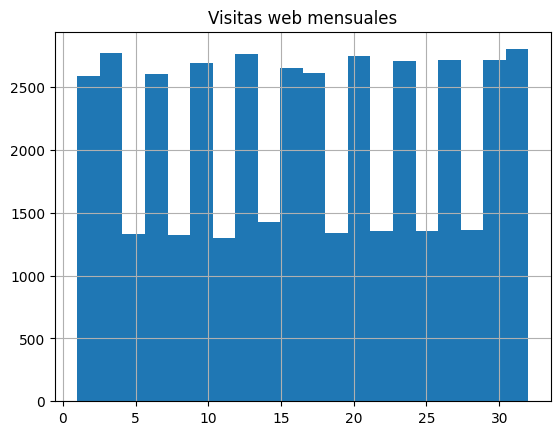

In [65]:
df_customers_clean["numwebvisitsmonth"].hist(bins=20)
plt.title("Visitas web mensuales")
plt.show()


# Cruce de datasframe

- Se observa, a primera vista que hay más clientes que a los registrados en la campaña de MK. 

¿No se ha llamado a la totalidad de los clientes? 

In [66]:
df_marketing_clean = pd.read_csv("../Datos/output/df_marketing_clean.csv")

In [67]:
df_customers_clean = pd.read_csv("../Datos/output/df_customers_clean.csv")

In [68]:
df_resultado = df_customers_clean.merge(
    df_marketing_clean,
    on='id',
    how='outer',
    indicator=True
)


In [69]:
df_resultado[['_merge']].value_counts()

_merge    
both          43000
left_only       170
right_only        0
Name: count, dtype: int64

In [70]:
df_resultado.groupby("y")["income"].mean().round(2)


y
no     93324.6
yes    92584.3
Name: income, dtype: float64

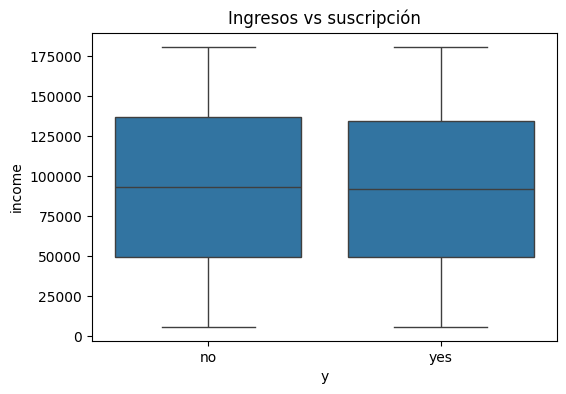

In [71]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_resultado, x="y", y="income")
plt.title("Ingresos vs suscripción")
plt.show()


In [72]:
df_resultado.groupby("y")["numwebvisitsmonth"].mean().round(2)


y
no     16.59
yes    16.60
Name: numwebvisitsmonth, dtype: float64

Una mayor interacción digital no garantiza conversión, pero aporta contexto de engagement.

NameError: name 'num_full' is not defined

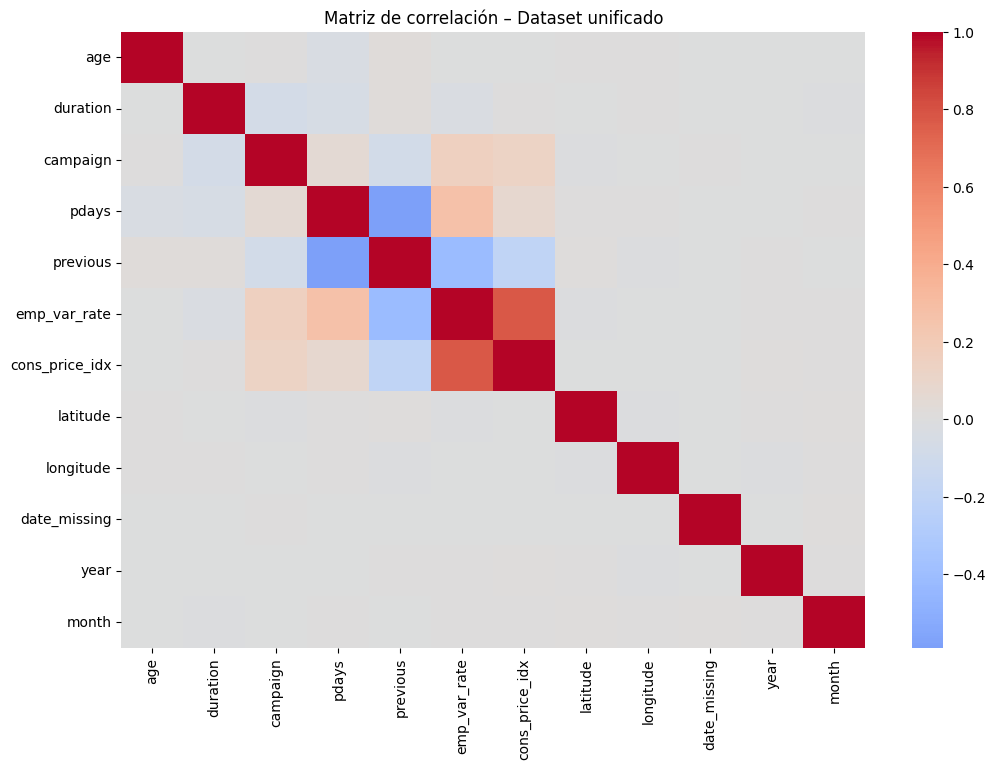

In [85]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de correlación – Dataset unificado")
plt.show()

La matriz de correlación del dataset unificado muestra relaciones coherentes entre variables macroeconómicas, que presentan correlaciones elevadas entre sí debido a su naturaleza estructural. En contraste, la mayoría de las variables de cliente y de campaña presentan correlaciones bajas con el resto, lo que indica que la conversión no responde a relaciones lineales simples. Este resultado es consistente con escenarios reales de marketing, donde el comportamiento del cliente depende de la interacción de múltiples factores y no de una única variable explicativa.